In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver #stores in ram

In [2]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [3]:
llm = ChatOpenAI()

def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [9]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)


chatbot = graph.compile(checkpointer=checkpointer)

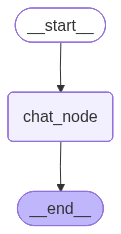

In [10]:
chatbot

In [12]:
initial_state = {
    'messages' : [HumanMessage(content='what is the capital of india')]
}

chatbot.invoke(initial_state)['messages'][-1].content

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [13]:
thread_id = '1'


while True:
    user_message = input('Type here: ')
    print(user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot.invoke({'messages' : [HumanMessage(content=user_message)]}, config= config)

    print('AI', response['messages'][-1].content)

my name is manavi
AI Hello Manavi, nice to meet you! How can I assist you today?
whats my name?
AI Your name is Manavi.
exit


In [14]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='my name is manavi', additional_kwargs={}, response_metadata={}, id='bbcbc2e4-31fe-47bc-8a2c-c367217bc339'), AIMessage(content='Hello Manavi, nice to meet you! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 12, 'total_tokens': 28, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DNJPDqAUe0mkoNCWVgz9Q3McDoPHe', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d255f-8774-7023-835b-e9ecd122d69a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 16, 'total_tokens': 28, 'input_token_details': {'audio'